In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [5]:
data = pd.read_csv("neutrino_flux.txt", sep="\s+")

In [6]:
data.head(16)

,#Site,Distance_km,Cores,ThermalPower_GW,Flux_cm2_s,Signal_per_yr
0,Kashiwazaki,160.0,7,24.6,425000.0,348.1
1,Ohi,179.5,4,13.7,188000.0,154.0
2,Takahama,190.6,4,10.2,124000.0,101.8
3,Hamaoka,214.0,4,10.6,103000.0,84.1
4,Tsuruga,138.6,2,4.5,103000.0,84.7
5,Shiga,80.6,1,1.6,108000.0,88.8
6,Mihama,145.4,3,4.9,103000.0,84.5
7,Fukushima-1,344.0,6,14.2,53000.0,43.5
8,Fukushima-2,344.0,4,13.2,49000.0,40.3
9,Tokai-II,294.6,1,3.3,17000.0,13.7


In [7]:
L = data['Distance_km'].to_numpy()[:16] # Only Japan reactors
Phi = data['Flux_cm2_s'].to_numpy()[:16] # Only Japan reactors

L_avg = np.sum(L*Phi)/np.sum(Phi)

print(f"The flux-weighted average reactor baseline is L = {L_avg:.2f} km.")

The flux-weighted average reactor baseline is L = 188.43 km.


In [4]:
prob_data = pd.read_csv("Survival Probability.csv",sep=",")

In [5]:
prob_data.head()

,x (L/E),P_ee
0,23.280901,0.588861
1,28.640297,0.640714
2,30.983967,0.689091
3,32.845137,0.868427
4,34.537226,0.724876


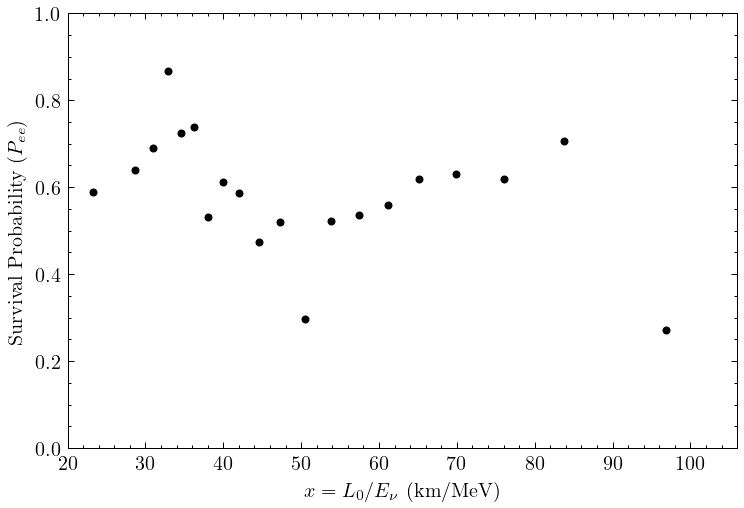

In [6]:
x= prob_data["x (L/E)"]
P_ee= prob_data["P_ee"]


# plt.figure(figsize=(8,6))
plt.plot(x, P_ee, "ok", ms = 3)


plt.xlim(20,106)
plt.ylim(0,1)

plt.xlabel(r"$x =L_0/E_{\nu}$ (km/MeV)")
plt.ylabel(r"Survival Probability ($P_{ee}$)")
plt.show()

In [54]:
E_nu = 180/x # Energy

In [13]:
P_ee_weighted = np.zeros_like(P_ee)

In [18]:
for i in range(len(P_ee)):
    P_ee_weighted[i]= np.sum(Phi*P_ee[i])/np.sum(Phi)

P_ee_weighted

array([0.58886114, 0.64071446, 0.68909098, 0.8684271 , 0.72487551,
       0.73787076, 0.53213684, 0.61180635, 0.58606701, 0.47407434,
       0.51990442, 0.29587826, 0.52142788, 0.53641165, 0.55862256,
       0.61905771, 0.62932114, 0.61970633, 0.70679188, 0.27172544])

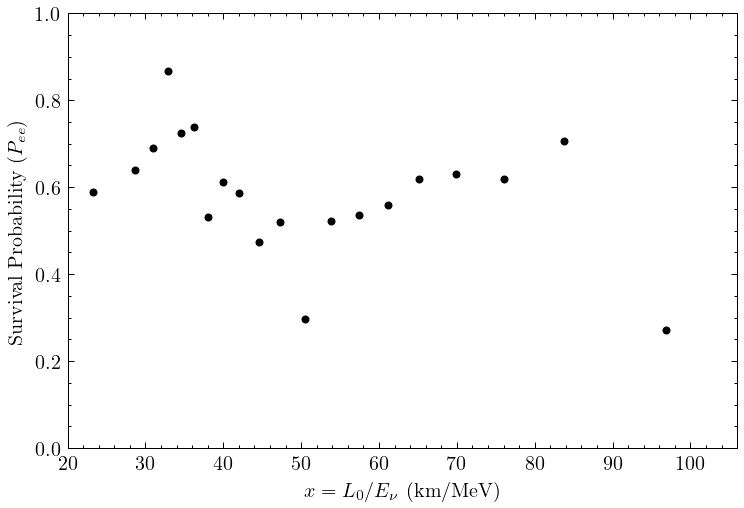

In [19]:
x= prob_data["x (L/E)"]
# P_ee= prob_data["P_ee"]


# plt.figure(figsize=(8,6))
plt.plot(x, P_ee_weighted, "ok", ms = 3)


plt.xlim(20,106)
plt.ylim(0,1)

plt.xlabel(r"$x =L_0/E_{\nu}$ (km/MeV)")
plt.ylabel(r"Survival Probability ($P_{ee}$)")
plt.show()

### The neutrino survival probability

The neutrino oscillation probability ($P_{ee}$) for both vacuum and dark mass hypothesis are as follows:

- Vacuum survival probability:
$$P_{ee} = 1 - \cos^{4}\theta_{13}\, \sin^{2} 2\theta_{12}\,\sin^{2}\left( 1.27\,\frac{\Delta m_{21}^{2}\,L}{E_\nu}
\right) - \sin^{2} 2\theta_{13}.$$

- Dark mass hypothesis:

  $$ P_{ee} = 1 - 2 \cos^{4}\theta_{13}\,\sin^{2}\theta_{12}\,\cos^{2}\theta_{12}\left[1- J_{0}\!\left(X_{21D}\right) \cos\!\left(X_{21D}\right) \right] - 2 \cos^{2}\theta_{13}\,\sin^{2}\theta_{13}.
  $$

Where, $$X_{ijD}= \frac{\Delta m_{ijD}^2\,L}{4 E},$$ where $m_\phi$ is the mass of ULDM, $J_0(z)$ is the bessel function of first kind.

In [37]:
param_names = [r'$\Delta m^{2}_{21}$', r'$\theta_{12}$', r'$\theta_{13}$']

In [48]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # dm21 varies between [1-15]* 10^(-5) eV^2
    hi= 15
    lo= 1
    params[0] = (cube[0] * (hi - lo) + lo) #*10**(-5)

    # theta_12 varies within [0-1]
    params[1] = cube[1]

    # theta_13 varies within [0-1]
    params[2] = cube[2]

    return params

In [124]:
from numpy import log

def my_likelihood(params):
    dm21, theta12, theta13 = params
    
    L = 180 #km
    E = 5 #MeV
    P_ee_err = 1.0
    
    # compute intensity at every x position according to the model
    P_ee_vac = 1 - np.cos(theta13)**4 * np.sin(2*theta12)**2 * np.sin(1.27*dm21*x* 10**(-2)) - np.sin(2*theta13)**2
    
    # compare model and data with gaussian likelihood:
    chi2 = np.sum(((P_ee_vac - P_ee)/P_ee)**2)
    like = -0.5 * chi2
    return like

In [50]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [51]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=-0.3  
[ultranest] Likelihood function evaluations: 11202
[ultranest]   logZ = -3.878 +- 0.05671
[ultranest] Effective samples strategy satisfied (ESS = 1576.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.06, need <0.5)
[ultranest]   logZ error budget: single: 0.07 bs:0.06 tail:0.01 total:0.06 required:<0.50
[ultranest] done iterating.

logZ = -3.859 +- 0.121
  single instance: logZ = -3.859 +- 0.073
  bootstrapped   : logZ = -3.878 +- 0.120
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $\Delta m^{2}_{21}$ : 1.0   │▇▆▅▃▃▃▂▂▂▃▂▃▂▂▂▃▃▂▃▂▂▃▂▂▃▄▅▅▅▅▅▅▄▃▃▃▃▂▃│15.0      8.0 +- 4.4
    $\theta_{12}$       : 0.00  │▇▅▅▆▆▆▄▅▆▅▄▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁▁▁│1.00      0.21 +- 0.15
    $\theta_{13}$       : 0.00  │▁▁▁▁▁▁▁▁▁▁▂▂▄▅▇▇▇▅▄▂▁▁▁▁

In [23]:
type(result)
result.keys()

dict_keys(['niter', 'logz', 'logzerr', 'logz_bs', 'logz_single', 'logzerr_tail', 'logzerr_bs', 'ess', 'H', 'Herr', 'posterior', 'weighted_samples', 'samples', 'maximum_likelihood', 'ncall', 'paramnames', 'logzerr_single', 'insertion_order_MWW_test'])

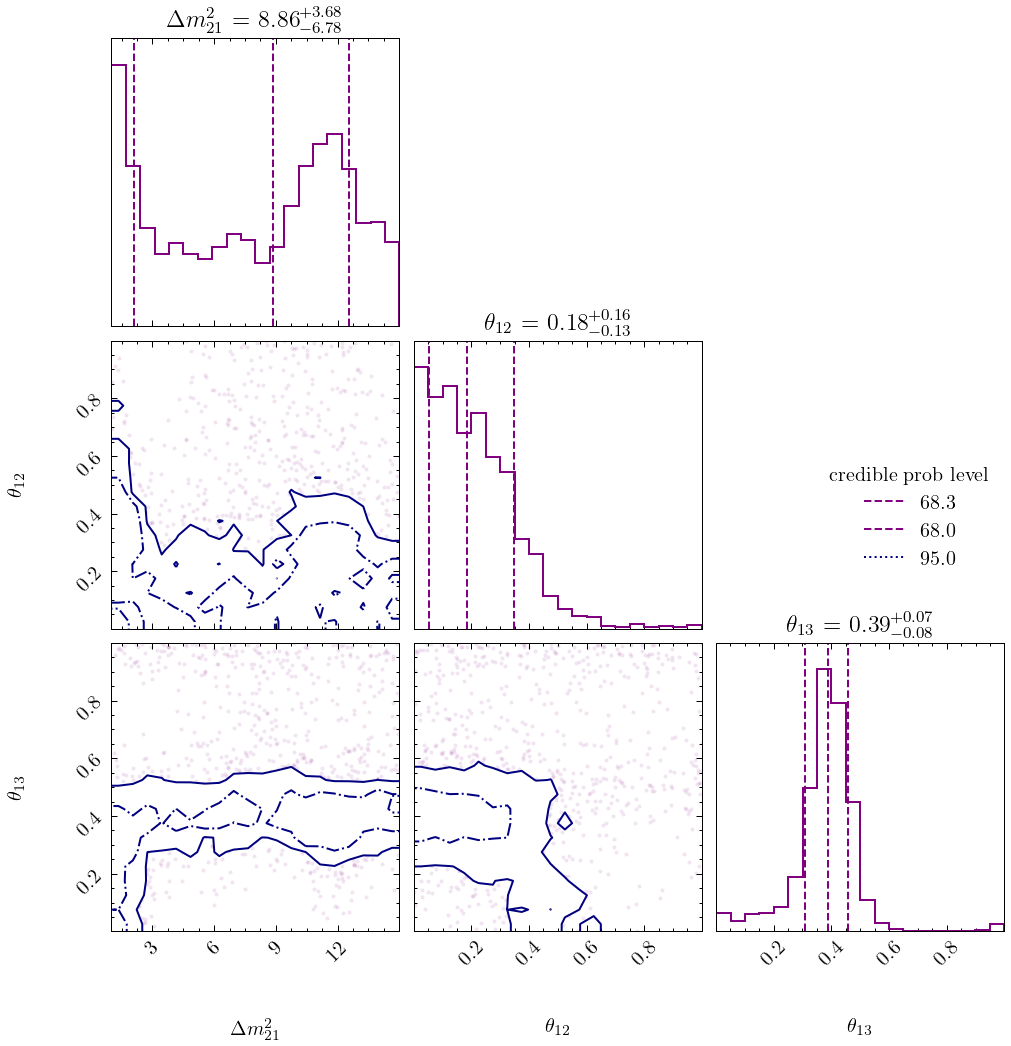

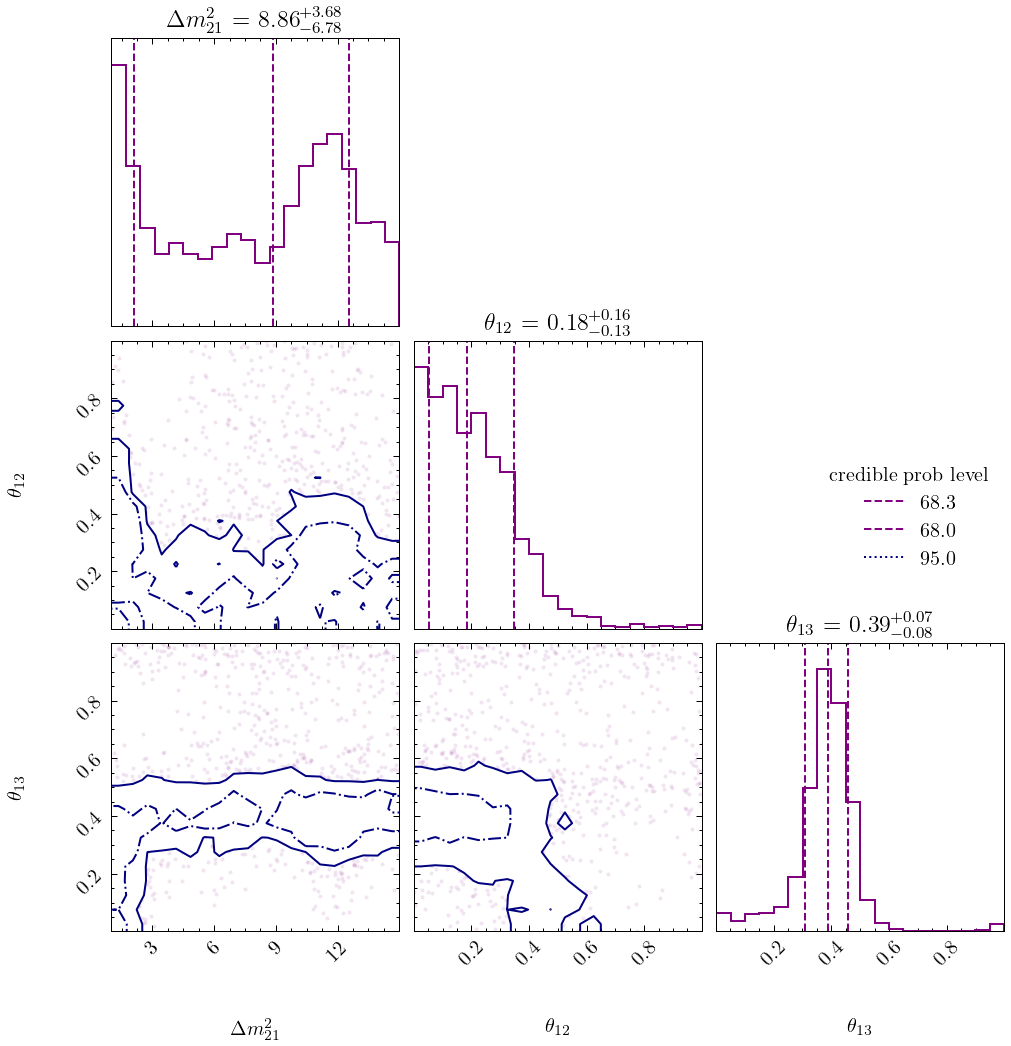

In [52]:
from ultranest.plot import cornerplot
fig= cornerplot(result,
                plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                color='black');

# plt.tight_layout()
plt.show()

### Playing with UltraNest Package

In [21]:
help(cornerplot)

Help on function cornerplot in module ultranest.plot:

cornerplot(results, min_weight=0.0001, with_legend=True, logger=None, levels=[0.9973, 0.9545, 0.6827, 0.3934], plot_datapoints=False, plot_density=False, show_titles=True, quiet=True, contour_kwargs={'linestyles': ['-', '-.', ':', '--'], 'colors': ['navy', 'navy', 'navy', 'purple']}, color='purple', quantiles=[0.15866, 0.5, 0.8413], **corner_kwargs)
    Make a healthy corner plot with corner.
    
    Essentially does::
    
        paramnames = results['paramnames']
        data = results['weighted_samples']['points']
        weights = results['weighted_samples']['weights']
    
        return corner.corner(
            results['weighted_samples']['points'],
            weights=results['weighted_samples']['weights'],
            labels=results['paramnames'])
    
    Parameters
    ----------
    results: dict
        data dictionary
    min_weight: float
        cut off low-weight posterior points. Avoids meaningless
        stra